In [24]:
import pandas as pd
read_file =r"C:\Users\syedb\Desktop\Equinox Quantitative Analytics and Predictive Platform\data\features\AAPL_1d_features.csv"
df = pd.read_csv(read_file)        
df[['Open','High','Low','Close']].describe()

,Open,High,Low,Close
count,2408.000000,2408.000000,2408.000000,2408.000000
mean,119.010402,120.190816,117.713170,118.899545
std,72.522834,73.209679,71.769947,72.458967
min,20.972174,21.202312,20.849129,21.168141
25%,44.546301,45.000734,44.251664,44.622381
50%,125.647606,127.382197,123.929626,125.507921
75%,173.803085,175.665778,171.873270,173.990110
max,285.922455,288.350192,283.035157,285.932471


In [29]:
import pandas as pd

# 1. Use .loc to avoid the 'SettingWithCopyWarning'
# 2. Use shift(-1) to look at the NEXT row's price
df.loc[:, 'target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# 3. Drop the last row (it will always be 0/NaN because there's no "next" day)
df = df.dropna(subset=['target']).copy()

# 4. CRITICAL: In Pandas 2.0+, you MUST specify numeric_only=True 
# if your dataframe contains strings/dates (like 'Ticker' or 'Date')
print(df.groupby('target').mean(numeric_only=True))

              Open        High         Low       Close        Volume  \
target                                                                 
0       120.801291  122.598391  119.965589  121.827784  9.999259e+07   
1       117.549058  118.226264  115.875224  116.510137  9.679049e+07   

              ADX    DI_plus   DI_minus       ATR  Ichimoku_conversion  \
target                                                                   
0       26.572691  22.211183  19.853600  3.281637           121.112068   
1       26.909600  23.823810  18.235814  3.104008           116.254073   

        Ichimoku_base  Ichimoku_spanA  Ichimoku_spanB  Ichimoku_lagging  
target                                                                   
0          120.187454      118.136314      116.236678        122.680123  
1          115.107083      112.775631      111.057330        120.526093  


In [28]:
import pandas as pd

# 1. Ensure 'target' is created correctly
# Using .shift(-1) moves tomorrow's price to today's row
df.loc[:, 'target'] = (df['Close'].shift(-1) > df['Close']).astype(int)

# 2. Clean up the NaN row created by the shift
df = df.dropna(subset=['target']).copy()

# 3. FIX: Add 'numeric_only=True' to the correlation method
# This prevents errors if you have Date or Text columns
correlations = df.corr(numeric_only=True)['target'].sort_values(ascending=False)

print(correlations)

target                 1.000000
DI_plus                0.116291
ADX                    0.016329
Ichimoku_lagging      -0.014631
Open                  -0.022311
Low                   -0.028356
Volume                -0.028994
High                  -0.029713
Ichimoku_conversion   -0.033456
Ichimoku_base         -0.035296
Close                 -0.036513
Ichimoku_spanB        -0.036999
Ichimoku_spanA        -0.037738
ATR                   -0.040502
DI_minus              -0.116604
Name: target, dtype: float64


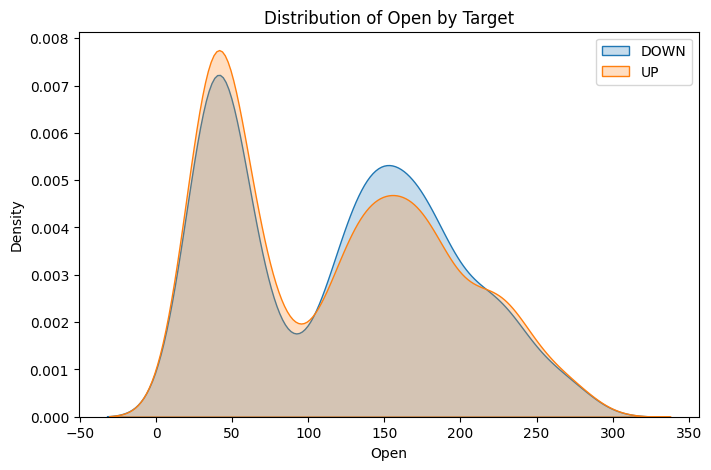

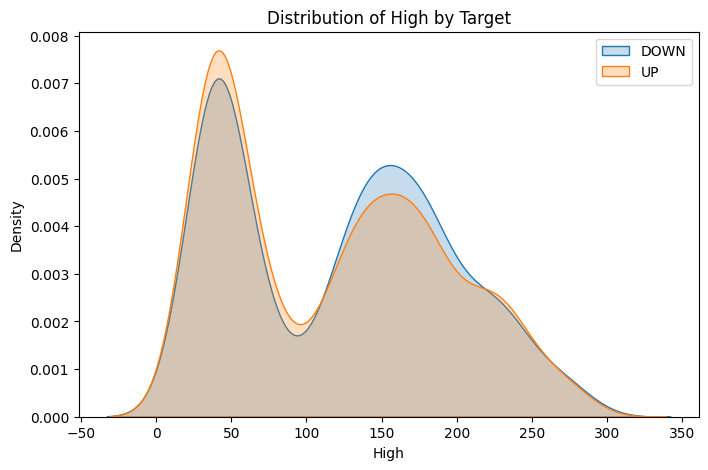

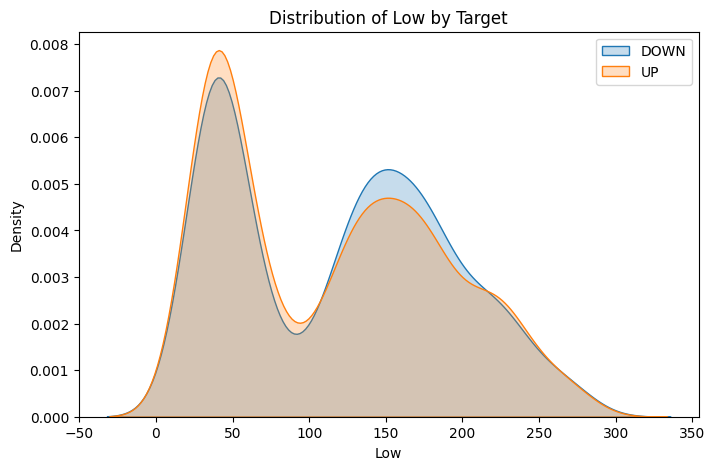

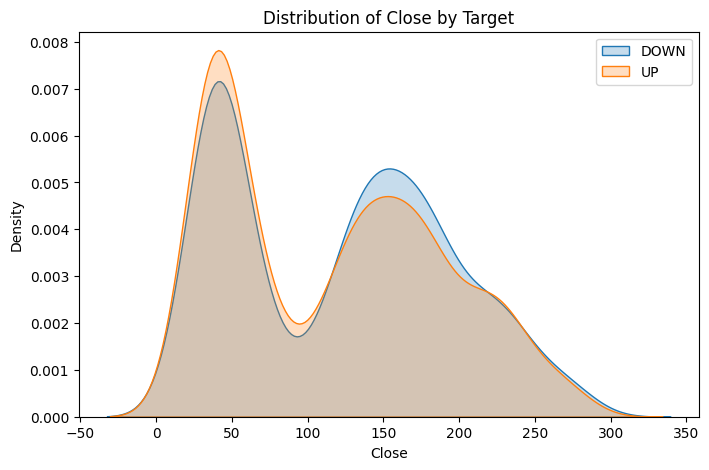

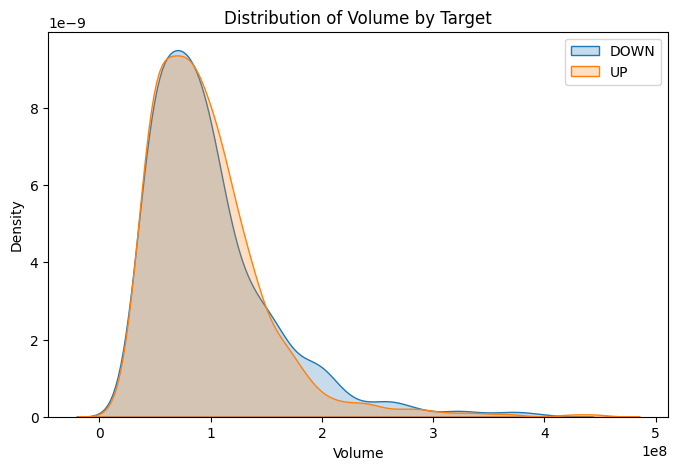

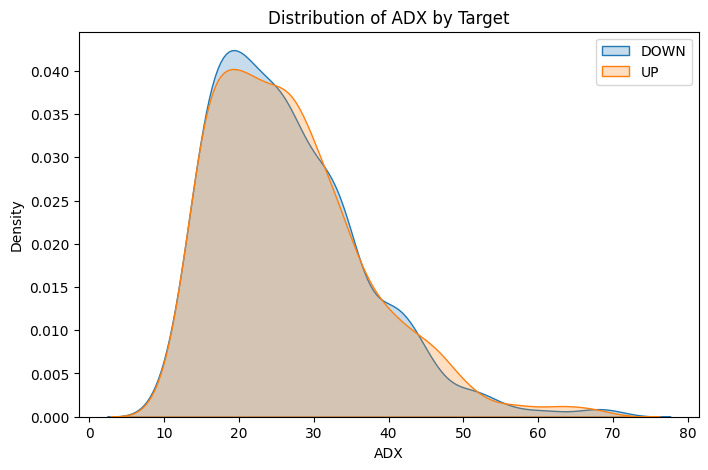

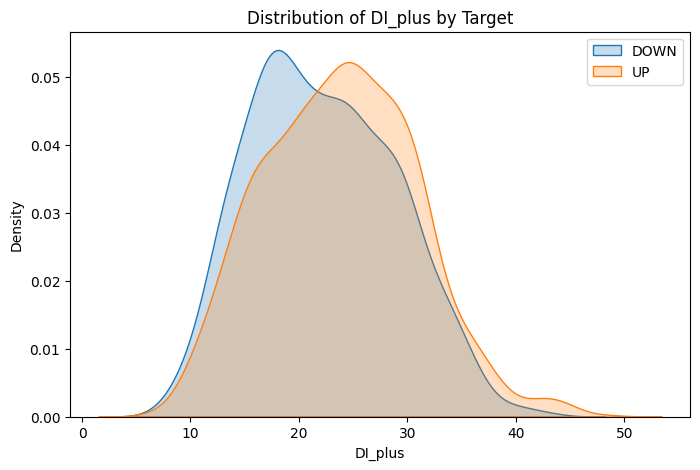

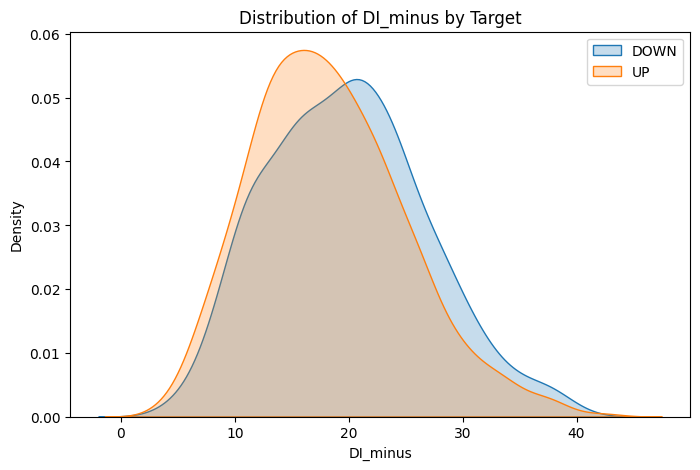

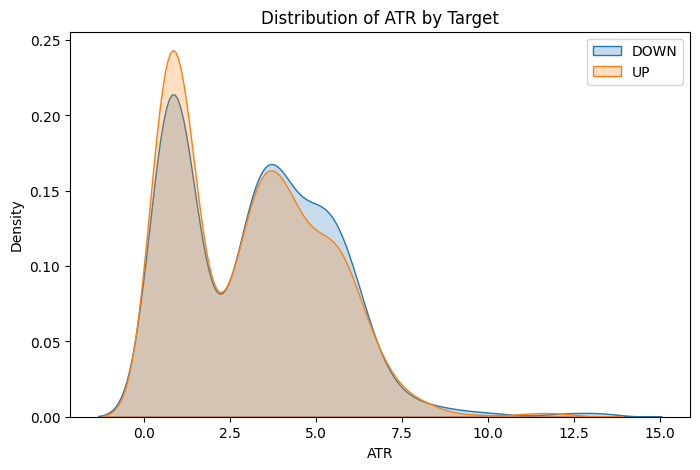

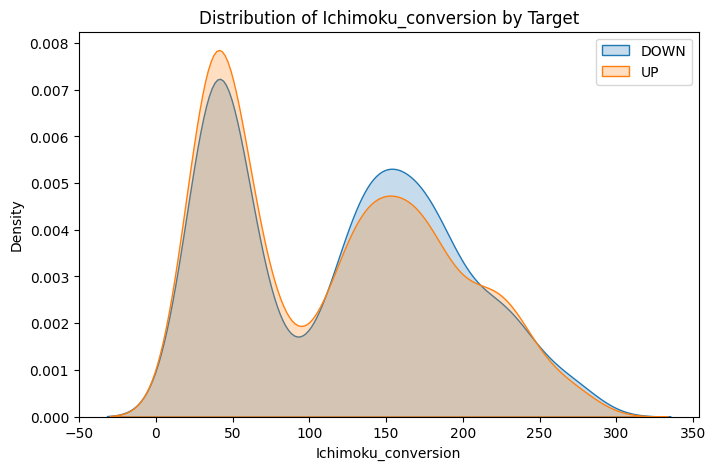

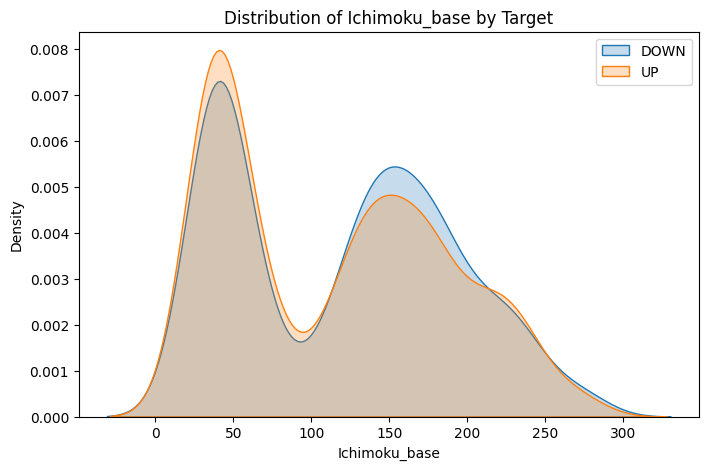

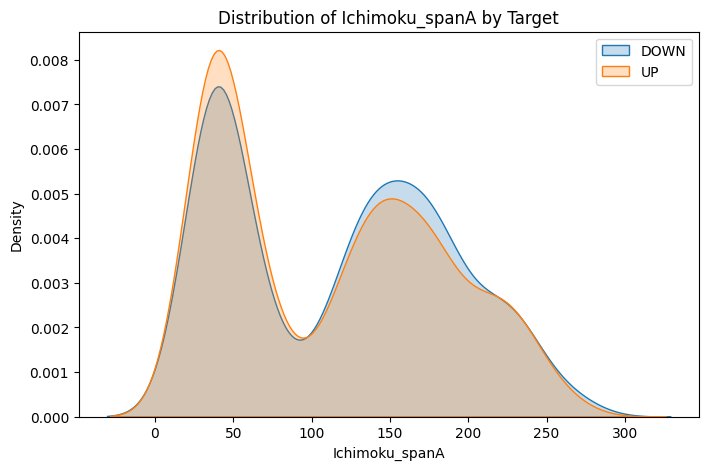

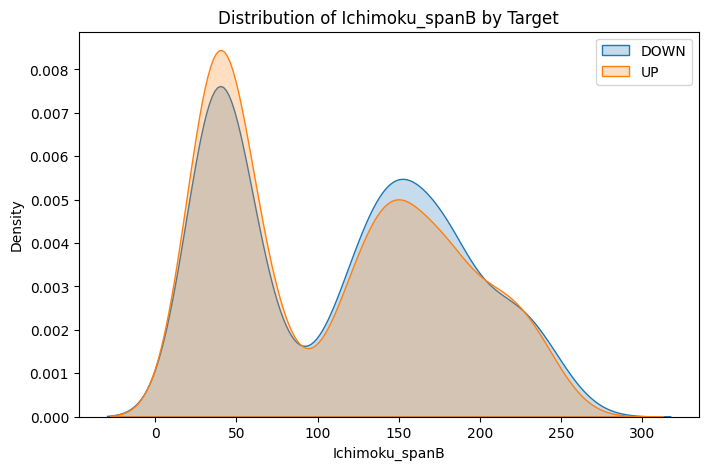

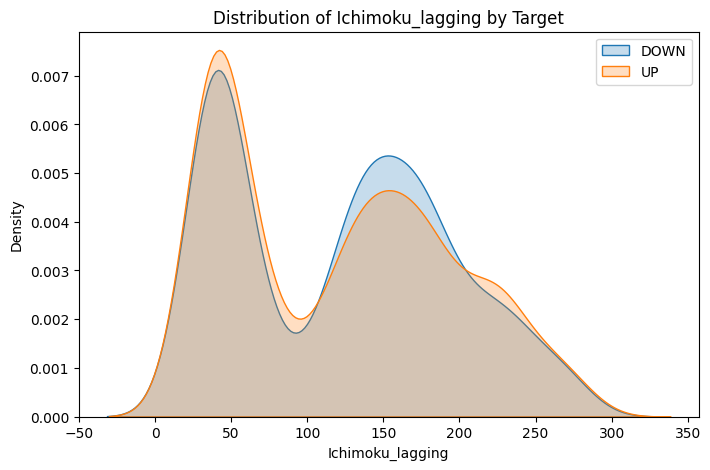

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create target & clean data
df.loc[:, 'target'] = (df['Close'].shift(-1) > df['Close']).astype(int)
df = df.dropna(subset=['target']).copy()

# 2. Iterate only through NUMERIC columns (excluding the target itself)
# This prevents errors from trying to plot 'Date' or 'Ticker' columns
numeric_cols = df.select_dtypes(include=['number']).columns

for col in numeric_cols:
    if col != 'target':
        plt.figure(figsize=(8, 5)) # Create a new figure for each plot
        
        # Check if column has data to avoid 'Dataset must contain at least two points' error
        if df[col].nunique() > 1:
            sns.kdeplot(data=df[df['target'] == 0], x=col, label='DOWN', fill=True)
            sns.kdeplot(data=df[df['target'] == 1], x=col, label='UP', fill=True)
            
            plt.title(f'Distribution of {col} by Target')
            plt.legend()
            plt.show()
        else:
            print(f"Skipping {col}: Not enough variance to plot.")


<Axes: >

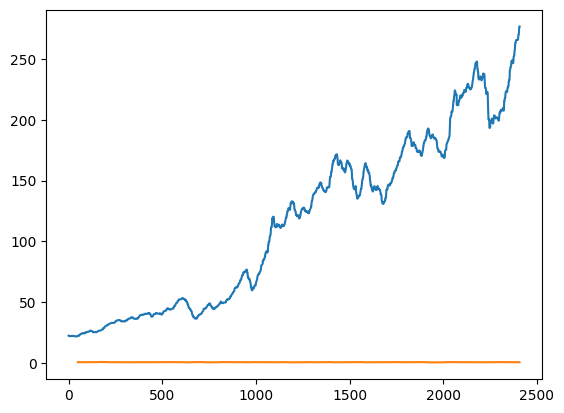

In [40]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df['Ichimoku_spanA'].plot()
df['target'].rolling(50).mean().plot()